In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time, random, os

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
if not os.path.exists("ECG5000_TRAIN.txt"):
    os.system('wget -q "https://www.timeseriesclassification.com/aeon-toolkit/ECG5000.zip"')
    os.system('unzip -q ECG5000.zip')

train_df = pd.read_csv("ECG5000_TRAIN.txt", header=None, sep=r'\s+')
test_df  = pd.read_csv("ECG5000_TEST.txt",  header=None, sep=r'\s+')

X_train_full = train_df.iloc[:, 1:].values.astype(np.float32)
y_train_full = train_df.iloc[:, 0].values
X_test_full  = test_df.iloc[:, 1:].values.astype(np.float32)
y_test_full  = test_df.iloc[:, 0].values

le = LabelEncoder()
y_train_full = le.fit_transform(y_train_full).astype(np.int64)
y_test_full  = le.transform(y_test_full).astype(np.int64)

def normalize_per_sample(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mean) / std

NUM_CLASSES = len(np.unique(y_train_full))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=128, num_layers=2, batch_first=True)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1])

In [5]:
def train_and_eval(seed, length, epochs=50, patience=10, lr=1e-3):
    set_seed(seed)

    X_norm = normalize_per_sample(X_train_full)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_norm, y_train_full, test_size=0.15, stratify=y_train_full, random_state=seed
    )
    X_test_norm = normalize_per_sample(X_test_full)

    X_tr_t   = torch.tensor(X_tr[:, :length]).unsqueeze(1)
    X_val_t  = torch.tensor(X_val[:, :length]).unsqueeze(1)
    X_test_t = torch.tensor(X_test_norm[:, :length]).unsqueeze(1)
    y_tr_t, y_val_t, y_test_t = torch.tensor(y_tr), torch.tensor(y_val), torch.tensor(y_test_full)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

    model = CNN_LSTM(NUM_CLASSES).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_acc, patience_counter = 0.0, 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                p = model(Xb.to(device)).argmax(dim=1).cpu().numpy()
                preds.extend(p); labels.extend(yb.numpy())
        val_acc = accuracy_score(labels, preds)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            p = model(Xb.to(device)).argmax(dim=1).cpu().numpy()
            preds.extend(p); labels.extend(yb.numpy())
    test_acc = accuracy_score(labels, preds)

    return test_acc

In [6]:
LENGTHS = list(range(30, 51))   # 30, 21, 22, ..., 50 -- 31 lengths
SEEDS = [0, 42, 123, 256, 789]  # 5 seeds

results = []

for length in LENGTHS:
    accs = []
    for seed in SEEDS:
        acc = train_and_eval(seed, length)
        accs.append(acc)
    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    print(f"T={length:>3} | mean: {mean_acc:.4f} | std: {std_acc:.4f} | accs: {[round(a,3) for a in accs]}")
    results.append({'length': length, 'mean_acc': mean_acc, 'std_acc': std_acc,
                     **{f'seed_{s}': a for s, a in zip(SEEDS, accs)}})

df = pd.DataFrame(results)
df.to_csv('lstm_fine_sweep_T20_T50.csv', index=False)

T= 30 | mean: 0.9016 | std: 0.0265 | accs: [0.904, 0.92, 0.85, 0.919, 0.915]
T= 31 | mean: 0.8753 | std: 0.0231 | accs: [0.877, 0.916, 0.873, 0.845, 0.865]
T= 32 | mean: 0.8821 | std: 0.0288 | accs: [0.912, 0.916, 0.873, 0.839, 0.87]
T= 33 | mean: 0.8683 | std: 0.0075 | accs: [0.878, 0.876, 0.864, 0.865, 0.858]
T= 34 | mean: 0.8665 | std: 0.0085 | accs: [0.88, 0.859, 0.872, 0.866, 0.856]
T= 35 | mean: 0.8592 | std: 0.0095 | accs: [0.854, 0.87, 0.865, 0.843, 0.864]
T= 36 | mean: 0.8621 | std: 0.0052 | accs: [0.867, 0.857, 0.856, 0.869, 0.862]
T= 37 | mean: 0.8577 | std: 0.0064 | accs: [0.861, 0.857, 0.866, 0.846, 0.859]
T= 38 | mean: 0.8567 | std: 0.0112 | accs: [0.861, 0.875, 0.857, 0.846, 0.845]
T= 39 | mean: 0.8511 | std: 0.0062 | accs: [0.851, 0.842, 0.861, 0.849, 0.852]
T= 40 | mean: 0.8504 | std: 0.0145 | accs: [0.862, 0.842, 0.827, 0.855, 0.867]
T= 41 | mean: 0.8350 | std: 0.0076 | accs: [0.824, 0.842, 0.836, 0.844, 0.829]
T= 42 | mean: 0.8540 | std: 0.0211 | accs: [0.893, 0.851,

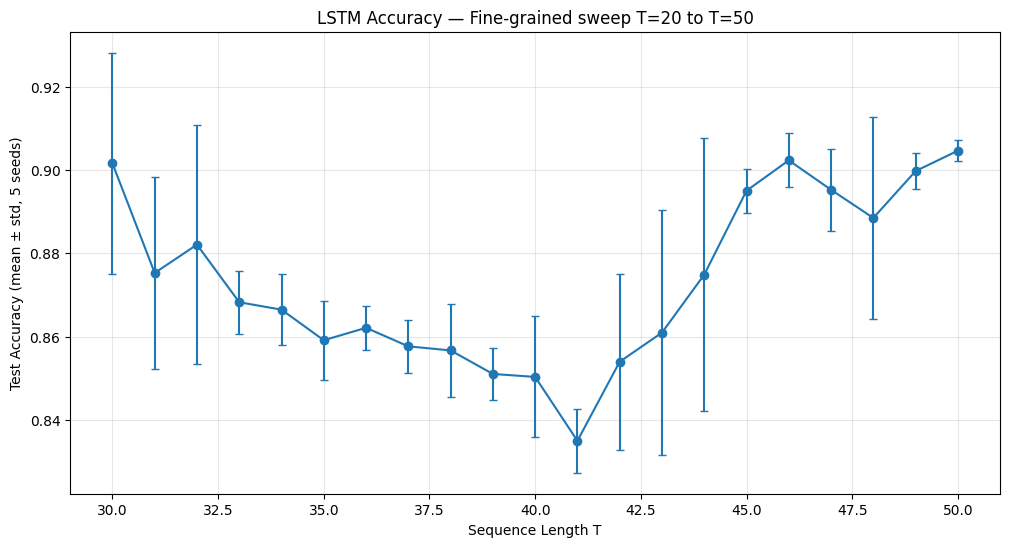

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.errorbar(df['length'], df['mean_acc'], yerr=df['std_acc'], marker='o', capsize=3)
plt.xlabel('Sequence Length T')
plt.ylabel('Test Accuracy (mean ± std, 5 seeds)')
plt.title('LSTM Accuracy — Fine-grained sweep T=20 to T=50')
plt.grid(True, alpha=0.3)
plt.savefig('lstm_fine_sweep_T20_T50.png', dpi=150, bbox_inches='tight')
plt.show()